In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('Titanic-Dataset.csv')
df.head(3)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [2]:
df.shape

(891, 11)

In [3]:
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
df.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [5]:
df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S


In [6]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [7]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [8]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [9]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [57]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [58]:
df['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


In [59]:
df['Parch'].value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [11]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [12]:
df['Sex'] = le.fit_transform(df['Sex']) # Male = 1, Female = 0

In [13]:
df['Sex'].value_counts()

,count
Sex,
1,577
0,314


In [14]:
df['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


In [15]:
df['Embarked'] = le.fit_transform(df['Embarked']) # S = 2, C = 0, Q = 1

In [16]:
df['Embarked'].value_counts()

,count
Embarked,
2,646
0,168
1,77


In [17]:
df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2


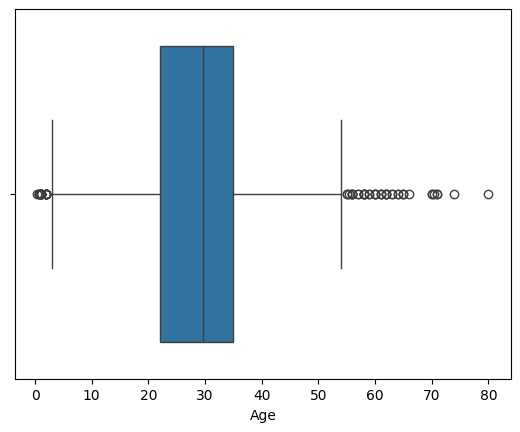

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Age', data=df)
plt.show()

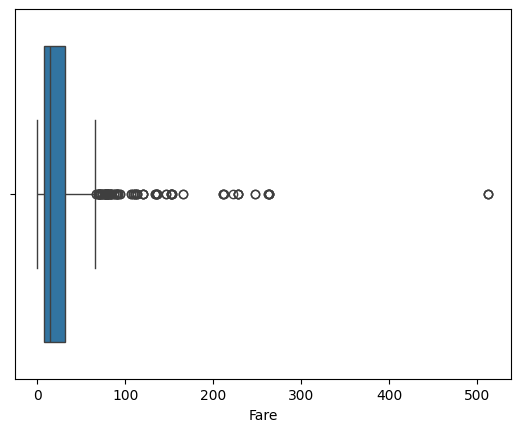

In [19]:
sns.boxplot(x='Fare', data=df)
plt.show()

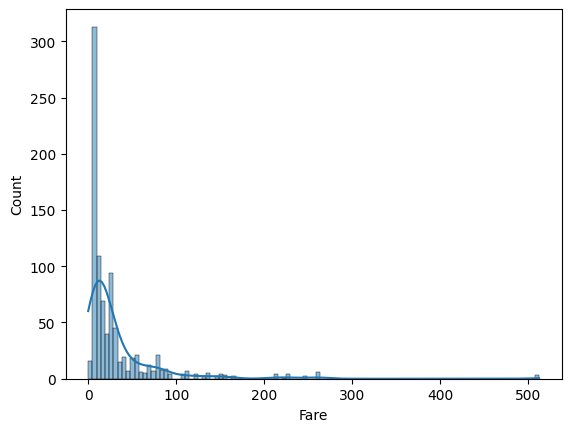

In [20]:
sns.histplot(df['Fare'], kde=True)
plt.show()

In [21]:
df.drop(columns=['Fare'], inplace=True)

In [22]:
df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,1,22.0,1,0,2
1,1,1,0,38.0,1,0,0
2,1,3,0,26.0,0,0,2


In [23]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X['Age'] = scaler.fit_transform(X[['Age']])

display(X.head())

,Pclass,Sex,Age,SibSp,Parch,Embarked
0,3,1,-0.592481,1,0,2
1,1,0,0.638789,1,0,0
2,3,0,-0.284663,0,0,2
3,1,0,0.407926,1,0,2
4,3,1,0.407926,0,0,2


In [25]:
# Let's say you have a new age input, for example, 30
new_age_input = np.array([[22]])

# Use the already fitted scaler to transform this new input
scaled_new_age = scaler.transform(new_age_input)

print(f"Original new age: {new_age_input[0][0]}")
print(f"Scaled new age: {scaled_new_age[0][0]}")

Original new age: 22
Scaled new age: -0.5924805998028931


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [26]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [27]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)

In [28]:
print('Original dataset shape %s' % y.value_counts())

X, y = sm.fit_resample(X, y)

print('Resampled dataset shape %s' % y.value_counts())

Original dataset shape Survived
0    549
1    342
Name: count, dtype: int64
Resampled dataset shape Survived
0    549
1    549
Name: count, dtype: int64


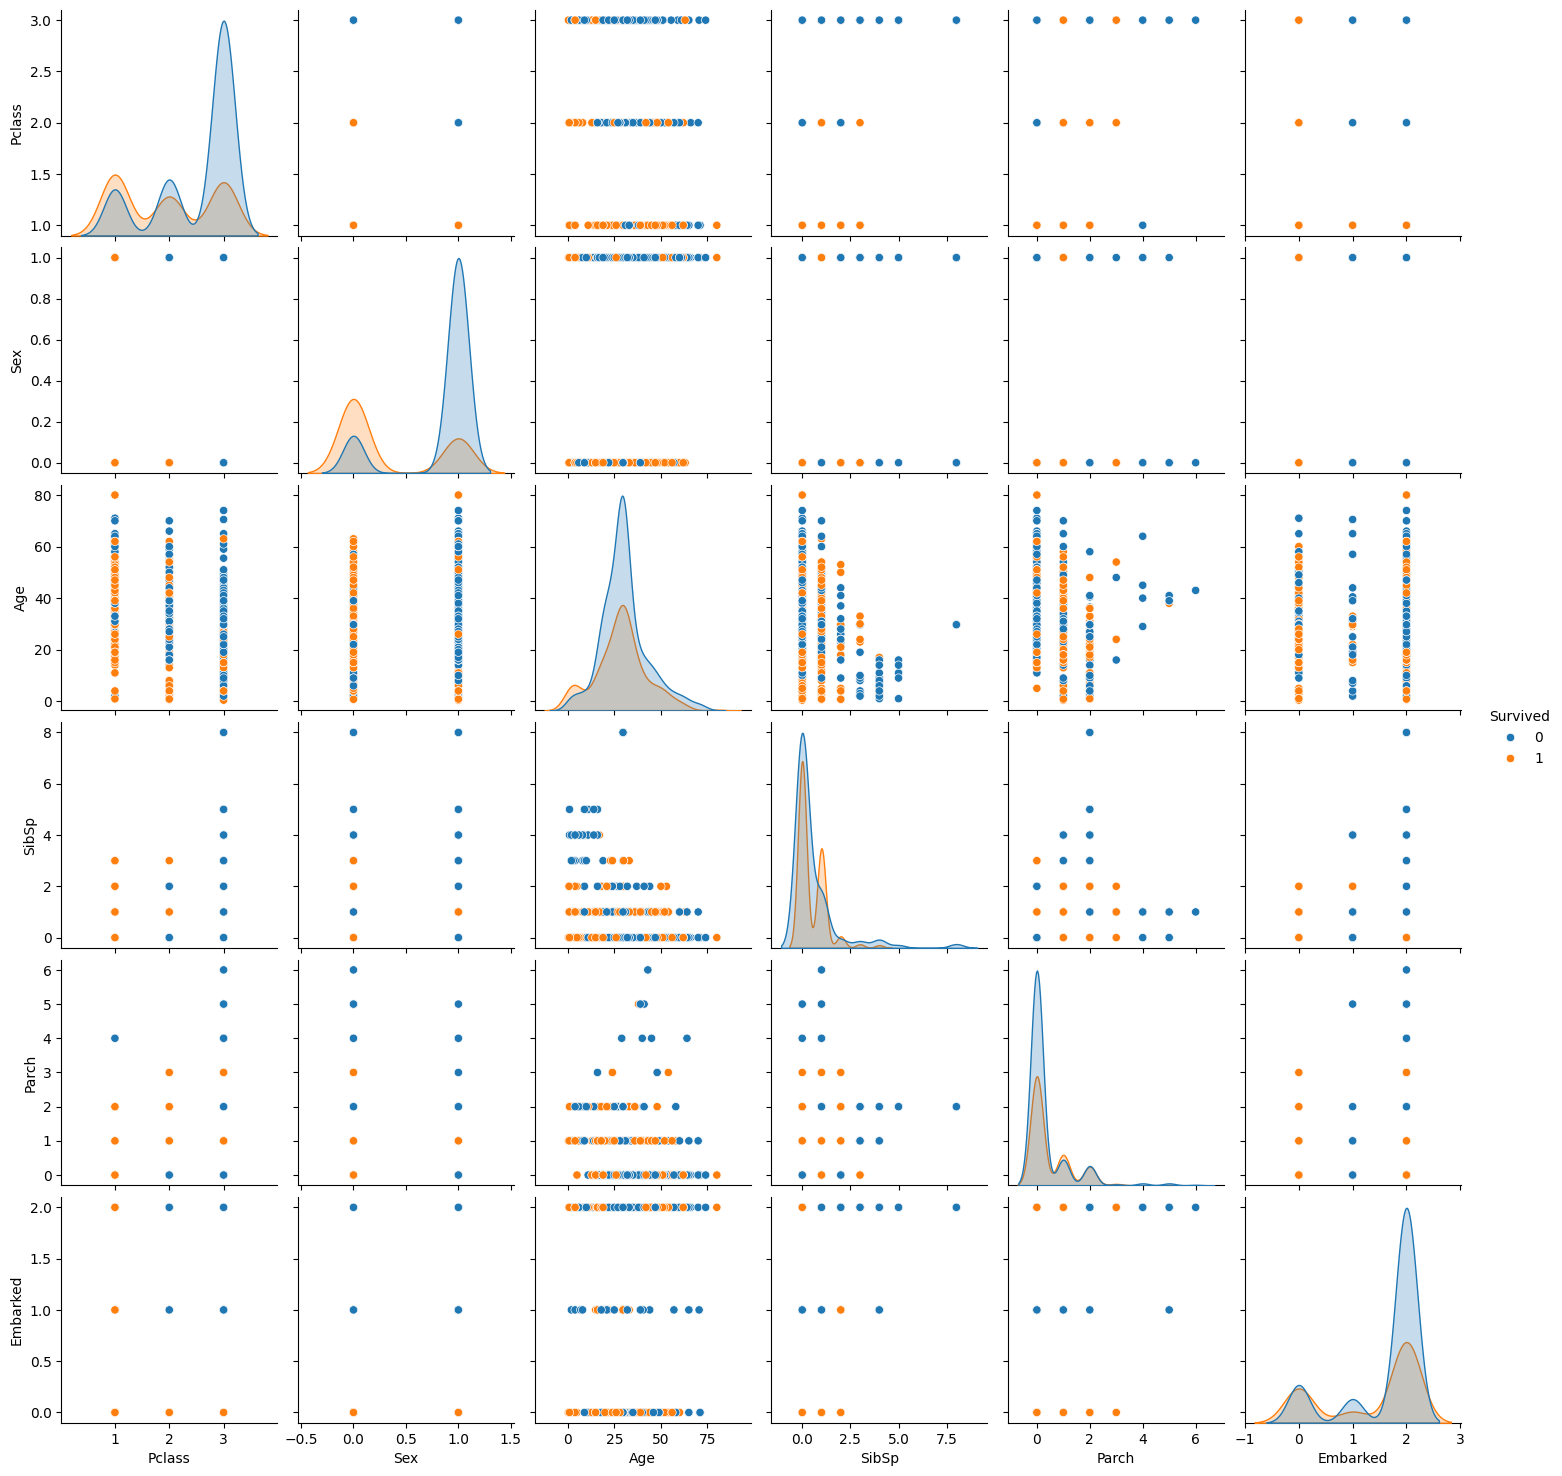

In [29]:
sns.pairplot(data=df, hue='Survived')
plt.show()

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [32]:
lr.score(X_train, y_train), lr.score(X_test, y_test)

(0.7984054669703873, 0.8181818181818182)

In [33]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [34]:
nb.score(X_train, y_train), nb.score(X_test, y_test)

(0.765375854214123, 0.8045454545454546)

In [35]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [36]:
dt.score(X_train, y_train), dt.score(X_test, y_test)

(0.9453302961275627, 0.8136363636363636)

In [37]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [38]:
knn.score(X_train, y_train), knn.score(X_test, y_test)

(0.8496583143507973, 0.7954545454545454)

In [39]:
from sklearn.svm import SVC

sv = SVC()
sv.fit(X_train, y_train)

SVC()

In [40]:
sv.score(X_train, y_train), sv.score(X_test, y_test)

(0.8143507972665148, 0.8409090909090909)

In [42]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(criterion='gini', max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=300, random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)

In [43]:
rfc.score(X_train, y_train), rfc.score(X_test, y_test)

(0.8917995444191344, 0.85)

In [44]:
from sklearn.ensemble import VotingClassifier

vc = VotingClassifier(estimators=[('Logistic Regression', lr), ('Naive Bayes', nb), ('Decision Tree', dt), ('KNN', knn), ('SVM', sv), ('Random Forest', rfc)], voting='hard')
vc.fit(X_train, y_train)

VotingClassifier(estimators=[('Logistic Regression', LogisticRegression()),
                             ('Naive Bayes', GaussianNB()),
                             ('Decision Tree', DecisionTreeClassifier()),
                             ('KNN', KNeighborsClassifier()), ('SVM', SVC()),
                             ('Random Forest',
                              RandomForestClassifier(min_samples_leaf=2,
                                                     min_samples_split=5,
                                                     n_estimators=300,
                                                     random_state=42))])

In [45]:
vc.score(X_train, y_train), vc.score(X_test, y_test)

(0.8656036446469249, 0.85)

In [46]:
from tensorflow import keras
from tensorflow.keras import layers

In [47]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5789 - loss: 0.6855 - val_accuracy: 0.5284 - val_loss: 0.6786
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6426 - loss: 0.6605 - val_accuracy: 0.6023 - val_loss: 0.6530
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6538 - loss: 0.6379 - val_accuracy: 0.6818 - val_loss: 0.6248
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6899 - loss: 0.6317 - val_accuracy: 0.6989 - val_loss: 0.5956
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7312 - loss: 0.5880 - val_accuracy: 0.7159 - val_loss: 0.5703
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7654 - loss: 0.5507 - val_accuracy: 0.7784 - val_loss: 0.5407
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7632 - loss: 0.5452 - val_accuracy: 0.7841 - val_loss: 0.5243
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7779 - loss: 0.5187 - val_accuracy: 0.7841 - val_loss

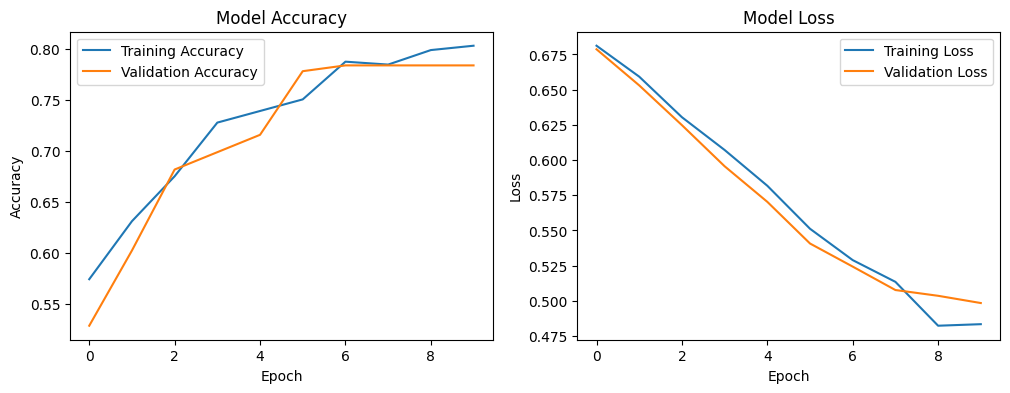

In [49]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [50]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# Perform 5-fold cross-validation on the Support Vector Classifier model
cv_scores = cross_val_score(sv, X, y, cv=5, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")

Cross-validation scores: [0.76818182 0.82272727 0.77272727 0.84474886 0.84474886]
Mean cross-validation accuracy: 0.8106


In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4], # Minimum number of samples required to be at a leaf node
    'criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}

# Initialize the Random Forest Classifier
rfc = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Get the best estimator
best_rfc = grid_search.best_estimator_

# Evaluate the best estimator on the test set
test_accuracy = best_rfc.score(X_test, y_test)
print(f"Test accuracy with best Random Forest model: {test_accuracy:.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters found: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best cross-validation accuracy: 0.8246
Test accuracy with best Random Forest model: 0.8500


In [53]:
new_age_value = 22

# Create a DataFrame for the new age value with the column name 'Age'
new_age_df = pd.DataFrame({'Age': [new_age_value]})
scaled_new_age = scaler.transform(new_age_df)[0][0]

input_data = pd.DataFrame({'Pclass': [3], 'Sex': [1], 'Age': [scaled_new_age], 'SibSp': [1], 'Parch': [0], 'Embarked': [2]})

prediction = best_rfc.predict(input_data)
print(prediction)

[0]


In [54]:
import pickle

with open('titanic_model.pkl', 'wb') as file:
    pickle.dump(best_rfc, file)

In [56]:
with open('age_scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)